In [1]:
# Zelle 1: Test import
from data_reconciliation.io.reader import read_excel
from data_reconciliation.preprocessing.filter import IQRFilter, ResidualFilter, CompositeFilter, filter_report
from data_reconciliation.reconciliation.reconcile import reconcile
from data_reconciliation.visualization.plots import plot_timeseries, plot_corrections
from data_reconciliation.visualization.save import save_figure
from data_reconciliation.reconciliation.balance import compute_mass_balance, BalanceReport
from pathlib import Path
import numpy as np 

print("✓ All modules imported")



✓ All modules imported


In [2]:
# Zelle 2: Read data
ROOT = Path().resolve().parent        # funktioniert in Notebooks aus notebooks/
data = read_excel(ROOT / "data" / "demo-daten_4.xlsx")
#help(read_excel)

X, A, rho          = data["X"], data["A"], data["rho"]
stream_ids         = data["stream_ids"]
stream_meta        = data["stream_meta"]   # dict {int: {klarname, nominal, einheit, typ}}
stream_names       = [stream_meta[sid]["klarname"] for sid in stream_ids]
balance_names      = data["balance_names"]

# Overview of data
print(f"Data sets: X: {X.shape}, A: {A.shape}, rho: {np.array(rho).shape}")
print(f"Stream meta: {stream_meta}")
print(f"Stream names: {stream_names}")
print(f"Balance names: {balance_names}")


Data sets: X: (3000, 6), A: (3, 6), rho: (6,)
Stream meta: {4: {'klarname': 'Rohbutan', 'nominal': 1000.0, 'einheit': 'kg/h', 'typ': 'Feed'}, 5: {'klarname': 'Synthesegas', 'nominal': 145.0, 'einheit': 'kg/h', 'typ': 'Feed'}, 6: {'klarname': 'Kreisgas', 'nominal': 100000.0, 'einheit': 'kg/h', 'typ': 'Rezirkulat'}, 9: {'klarname': 'Reaktorausgang', 'nominal': 101145.0, 'einheit': 'kg/h', 'typ': 'intern (eingeführt)'}, 12: {'klarname': 'Valeraldehyd', 'nominal': 1135.0, 'einheit': 'kg/h', 'typ': 'Produktstrom'}, 14: {'klarname': 'Purge', 'nominal': 10.0, 'einheit': 'kg/h', 'typ': 'Abgasstrom'}}
Stream names: ['Rohbutan', 'Synthesegas', 'Kreisgas', 'Reaktorausgang', 'Valeraldehyd', 'Purge']
Balance names: ['Gesamtbilanz', 'Reaktor', 'Trennung/Flash']


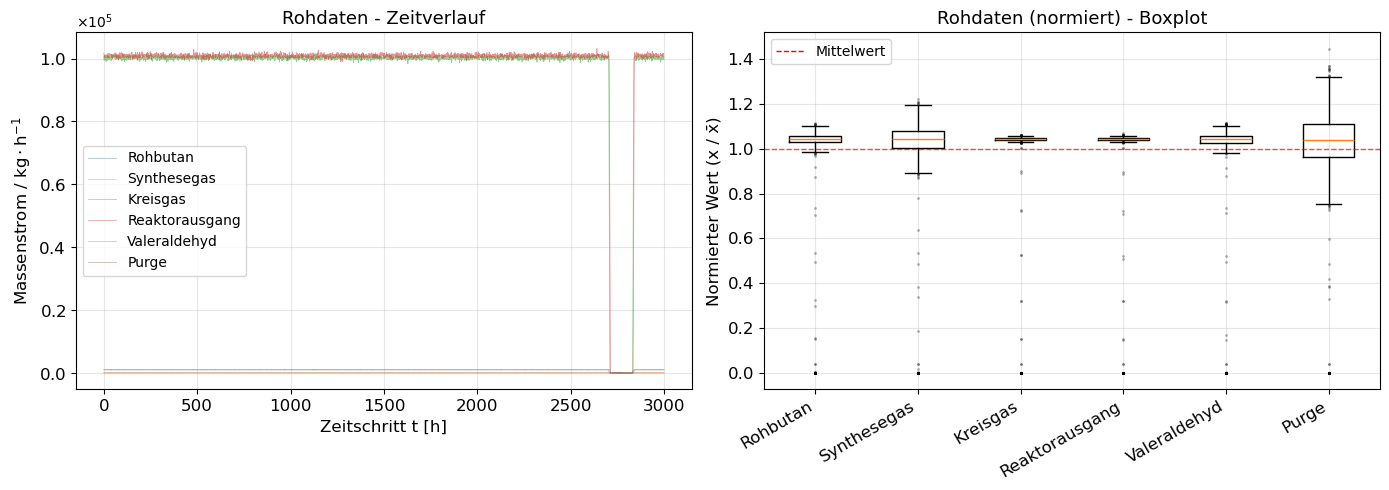

In [3]:
# Plot raw data
#help(plot_timeseries)
fig1 = plot_timeseries(X, 
                       mask=None,
                       labels=stream_names,
                       normalize=True,
                       sci_left=True,
                       sci_right=False,
                       ylabel_left=r"Massenstrom / $\mathrm{kg \cdot h^{-1}}$",
                       ylabel_right="",
                       title_left="Rohdaten - Zeitverlauf",
                       title_right="Rohdaten (normiert) - Boxplot")
#save_figure(fig1)

---------------------------------------------
  Filterung: 3000 Zeitschritte total
  Behalten:  2774  (92.5%)
  Entfernt:  226  (7.5%)
---------------------------------------------


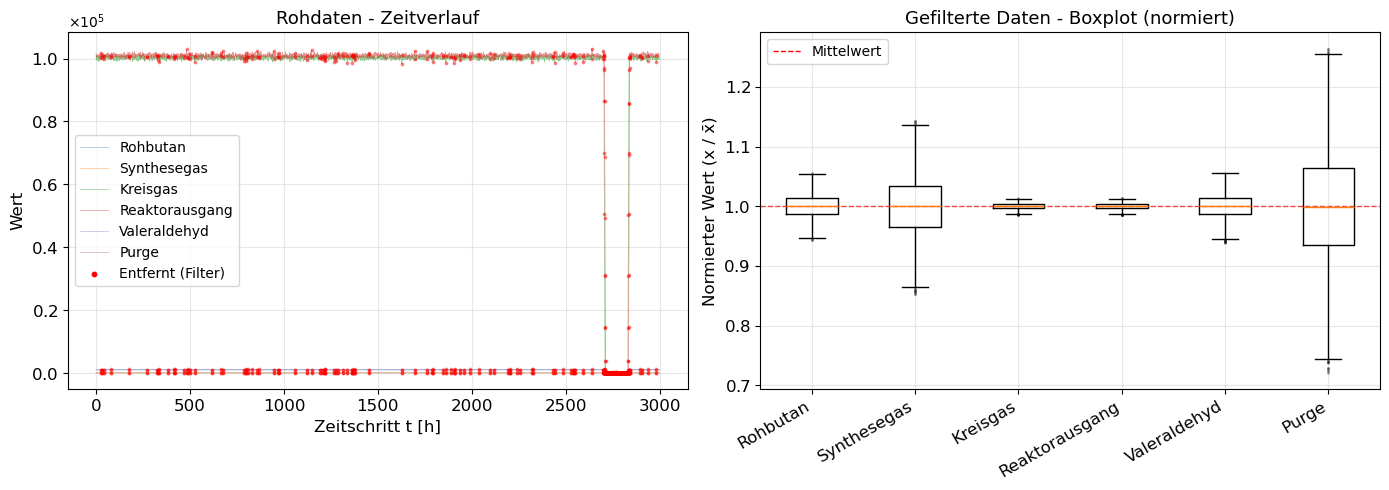

In [4]:
# Zelle 3: Filtern der Daten
# f = CompositeFilter([IQRFilter(k=1.5), ResidualFilter(A, threshold=3.0)], mode="and")
# f = CompositeFilter([IQRFilter(k=1.5), ResidualFilter(A, threshold=3.0)], mode="and")
# detailed = f.fit(X).transform_detailed(X)
# mask = detailed["combined"]
# filter_report(mask, detailed)

# Simple IQR-Filter / Tukey Fence
f = IQRFilter(k=1.5)         # k = 1,5: Inner fence
mask = f.fit_transform(X)
filter_report(mask)

# Zelle 5: Plot filtered data
%matplotlib inline
fig2 = plot_timeseries(X, 
                       mask=mask,
                       labels=stream_names,
                       normalize=True,
                       sci_left=True,
                       sci_right=True,
                       title_left="Rohdaten - Zeitverlauf",
                       title_right="Gefilterte Daten - Boxplot (normiert)")
#save_figure(fig2)




In [5]:
# Generate report
report = BalanceReport(A, balance_names, eng_unit="kg/h")
report.add("Rohdaten",    X)
report.add("Gefiltert",   X[mask])
#report.add("Rekonziliert", X_rec)

#report.table()           # schöne Tabelle im Notebook
#print(report.table())    # Textausgabe in der Konsole
report.table().loc[["Gesamtbilanz"]] # nur eine Bilanz

Datensatz                          Rohdaten  Gefiltert
Bilanzraum   Metrik                                   
Gesamtbilanz N                      3000.00    2774.00
             Input [kg/h]           1096.00    1145.00
             Output [kg/h]          1079.00    1127.00
             Residual abs. [kg/h]    -17.76     -18.76
             Residual rel. [%]        -1.62      -1.64

Mittlere Bilanzabweichung (ungefiltert): [  17.76305667  498.11749667 -480.35444   ]
Mittlere Bilanzabweichung (gefiltert): [  18.7636013   520.34235761 -501.57875631]


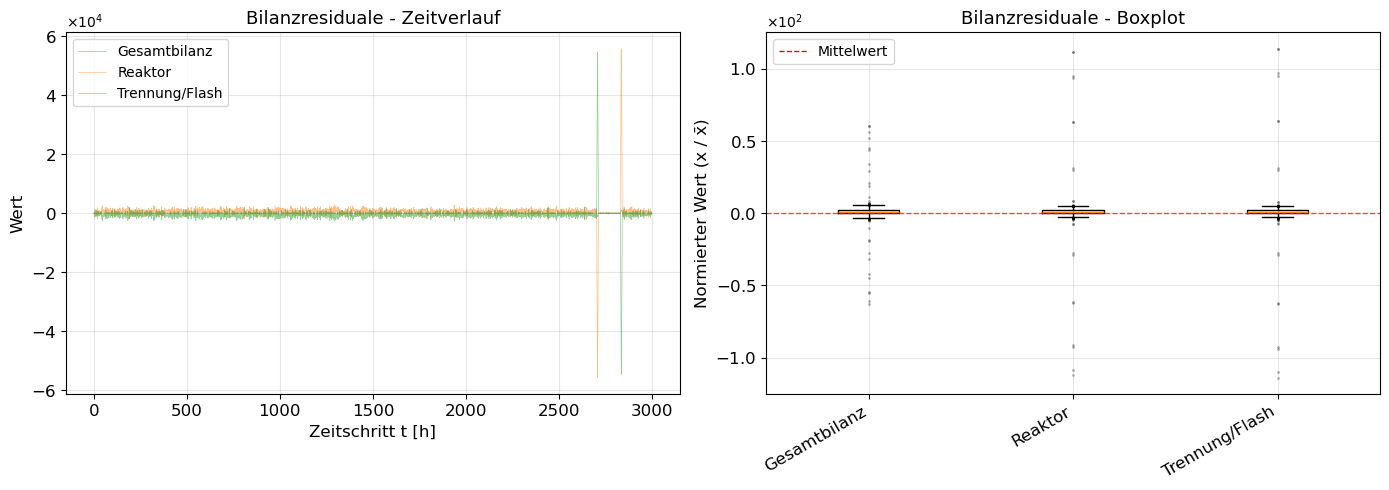

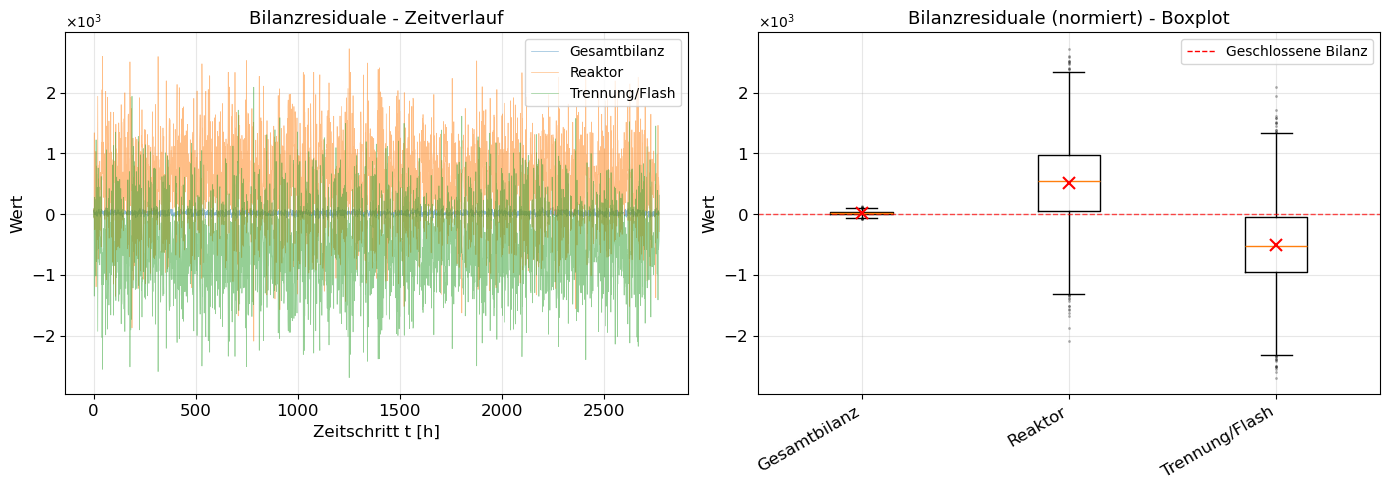

In [13]:
# Massenbilanz ungefiltert
mb_uf = compute_mass_balance(X, A)
print(f'Mittlere Bilanzabweichung (ungefiltert): { mb_uf["residuals_mean"] }')
all_residuals = mb_uf['residuals']
fig1 = plot_timeseries(X=all_residuals,
                    labels=balance_names,
                    title_left= "Bilanzresiduale - Zeitverlauf",
                    title_right= "Bilanzresiduale - Boxplot",
                    xlabel="Zeitschritt t [h]",
                    normalize=True,
                    hline=0,
                    sci_left=True,
                    sci_right=True)


# Massenbilanz gefiltert
mb_f = compute_mass_balance(X_stat, A)
print(f'Mittlere Bilanzabweichung (gefiltert): { mb_f["residuals_mean"] }')
all_residuals = mb_f['residuals']
fig2 = plot_timeseries(X=all_residuals,
                    labels=balance_names,
                    title_left= "Bilanzresiduale - Zeitverlauf",
                    title_right= "Bilanzresiduale (normiert) - Boxplot",
                    xlabel="Zeitschritt t [h]",
                    normalize=False,
                    hline=True,
                    hline_label="Geschlossene Bilanz",
                    sci_left=True,
                    sci_right=True)

In [6]:
# Zelle 4: Rekonziliation
result = reconcile(X[mask], A, rho)
print(f"Mittlerer SS_res: {result['SS_res'].mean():.6f}")



Mittlerer SS_res: 596.734447


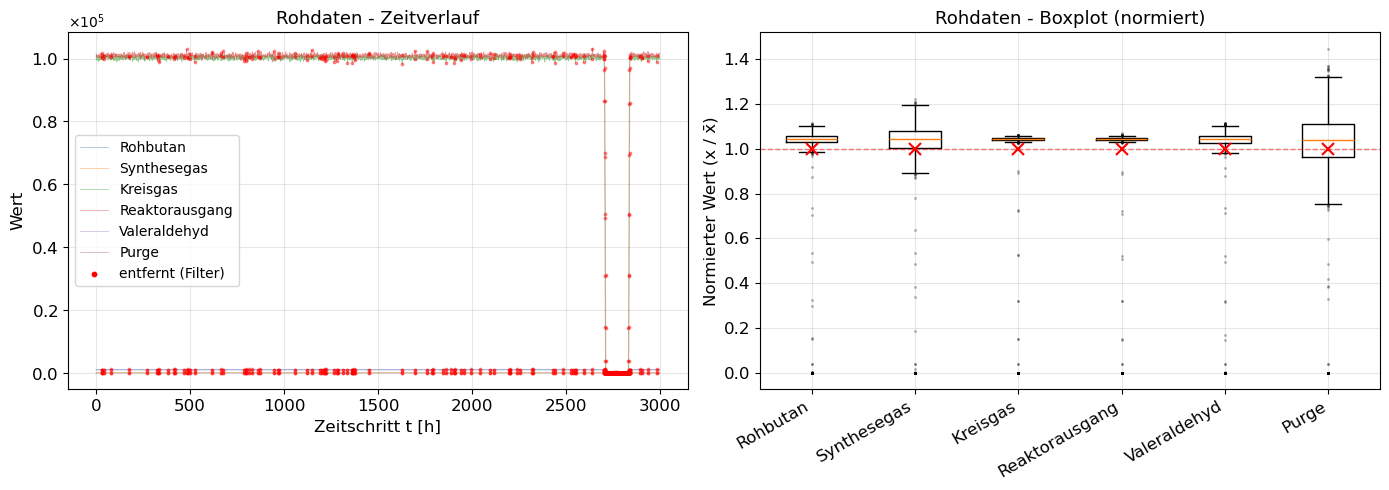

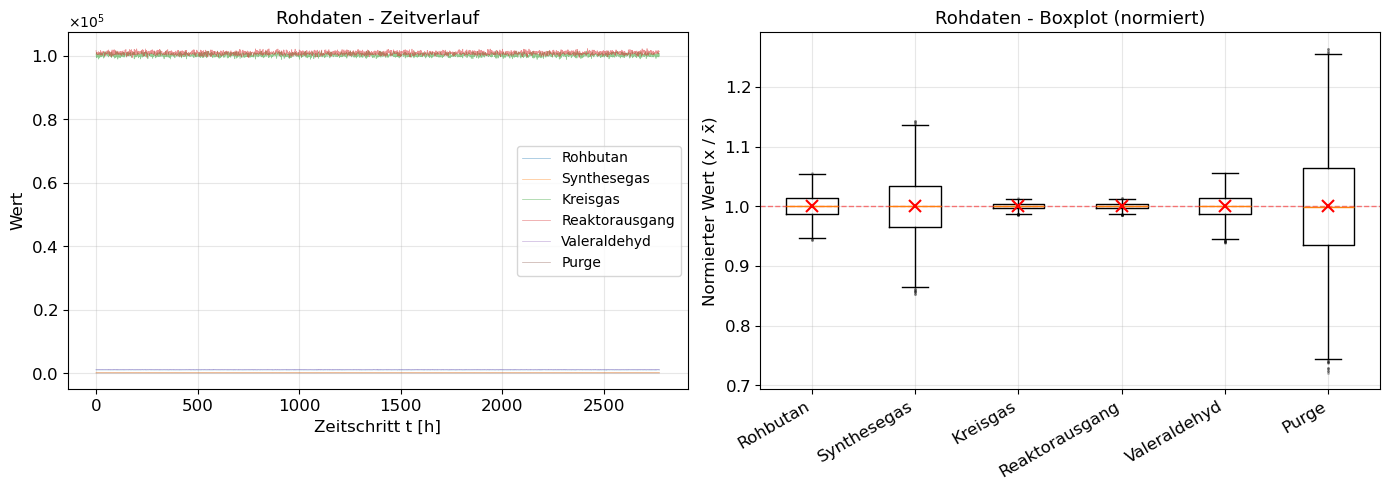

In [6]:
save_figure(fig1)
save_figure(fig2)

  Gespeichert: C:\Users\Admin\Nextcloud-RP\997_Python-Projekte\data-reconciliation\notebooks\docs\plots\2026-03-10_10-55_rohdaten_zeitverlauf.png  (156 KB)
  Gespeichert: C:\Users\Admin\Nextcloud-RP\997_Python-Projekte\data-reconciliation\notebooks\docs\plots\2026-03-10_10-55_rohdaten_gefiltert_-_zeitverlauf.png  (134 KB)


'C:\\Users\\Admin\\Nextcloud-RP\\997_Python-Projekte\\data-reconciliation\\notebooks\\docs\\plots\\2026-03-10_10-55_rohdaten_gefiltert_-_zeitverlauf.png'